In [1]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
#---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [2]:
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])

    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

In [3]:
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])

    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

In [4]:
tr_df = train_df('train')

In [5]:
tr_df

,Class Path,Class
0,train\Caries\100_jpg.rf.49fe262ac5f98ad55bde08...,Caries
1,train\Caries\100_jpg.rf.a05f1a66f021b0b4b5033e...,Caries
2,train\Caries\100_jpg.rf.b4d442ffbb075f71203abd...,Caries
3,train\Caries\101_jpg.rf.3752d4aaca733760e63cd5...,Caries
4,train\Caries\101_jpg.rf.445071b9149768e692f6a9...,Caries
...,...,...
1071,train\Healthy Teeth\96_jpg.rf.403265bc16d6833d...,Healthy Teeth
1072,train\Healthy Teeth\96_jpg.rf.65c5b1574e4f423b...,Healthy Teeth
1073,train\Healthy Teeth\9_jpg.rf.21986376f783646c4...,Healthy Teeth
1074,train\Healthy Teeth\9_jpg.rf.ab2176791c03edfa4...,Healthy Teeth


In [6]:
ts_df = test_df('test')

In [7]:
ts_df

,Class Path,Class
0,test\Caries\100_jpg.rf.49fe262ac5f98ad55bde08d...,Caries
1,test\Caries\100_jpg.rf.a05f1a66f021b0b4b5033ea...,Caries
2,test\Caries\100_jpg.rf.b4d442ffbb075f71203abdf...,Caries
3,test\Caries\101_jpg.rf.3752d4aaca733760e63cd55...,Caries
4,test\Caries\101_jpg.rf.445071b9149768e692f6a92...,Caries
...,...,...
1071,test\Healthy Teeth\96_jpg.rf.403265bc16d6833d2...,Healthy Teeth
1072,test\Healthy Teeth\96_jpg.rf.65c5b1574e4f423b4...,Healthy Teeth
1073,test\Healthy Teeth\9_jpg.rf.21986376f783646c44...,Healthy Teeth
1074,test\Healthy Teeth\9_jpg.rf.ab2176791c03edfa4b...,Healthy Teeth


In [8]:
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])

In [9]:
valid_df

,Class Path,Class
787,test\Ectopic\3_bmp_jpg.rf.aff249506ce5bf168299...,Ectopic
364,test\Decayed Tooth\C-26_jpg.rf.32a5c1127d7e848...,Decayed Tooth
193,test\Caries\42_jpg.rf.a3a98cbd7a2cfa0ba78e3f88...,Caries
152,test\Caries\226_jpg.rf.4ba1cf38db0142201674ffe...,Caries
1046,test\Healthy Teeth\27_jpg.rf.344874918cd61f89c...,Healthy Teeth
...,...,...
295,test\Decayed Tooth\C-115_jpg.rf.7851232f7a7fbd...,Decayed Tooth
279,test\Decayed Tooth\472_jpg.rf.3003f8e5b59574fb...,Decayed Tooth
713,test\Ectopic\36463954000-FATIMA-NUR-ARIYEL-7YA...,Ectopic
753,test\Ectopic\37814018754-ELIF-NAZ-KILIC-6YAS_b...,Ectopic


In [10]:
batch_size = 32
img_size = (299, 299)

_gen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

ts_gen = ImageDataGenerator(rescale=1/255)


tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=16,
                                  target_size=img_size, shuffle=False)

Found 1076 validated image filenames belonging to 4 classes.
Found 538 validated image filenames belonging to 4 classes.
Found 538 validated image filenames belonging to 4 classes.


Class Distribution in the Training Dataset:
Class
Ectopic          375
Decayed Tooth    336
Caries           249
Healthy Teeth    116
Name: count, dtype: int64


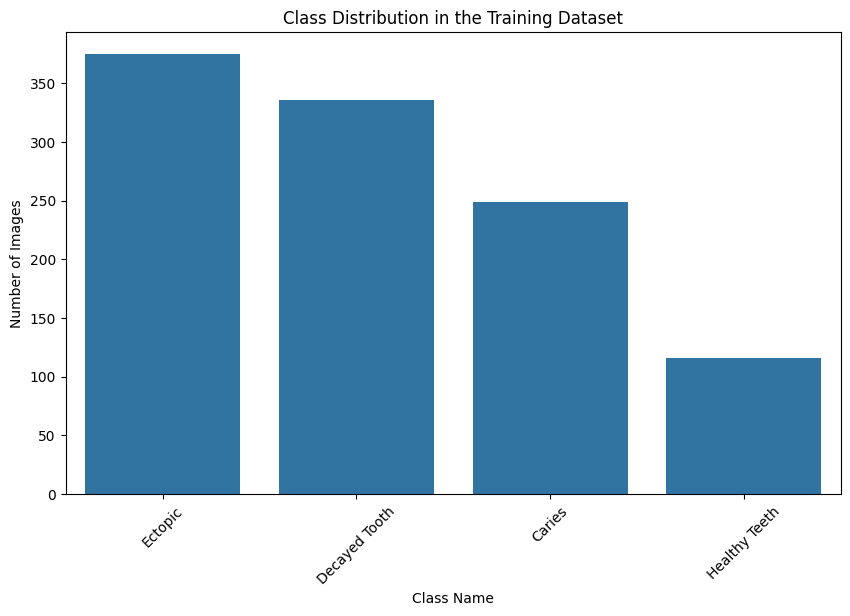

In [11]:
# Display the number of samples (images) in each class in the training dataset
class_counts = tr_df['Class'].value_counts()

# Display the class names and their corresponding counts
print("Class Distribution in the Training Dataset:")
print(class_counts)

# Optionally, you can plot the distribution as a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution in the Training Dataset')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()


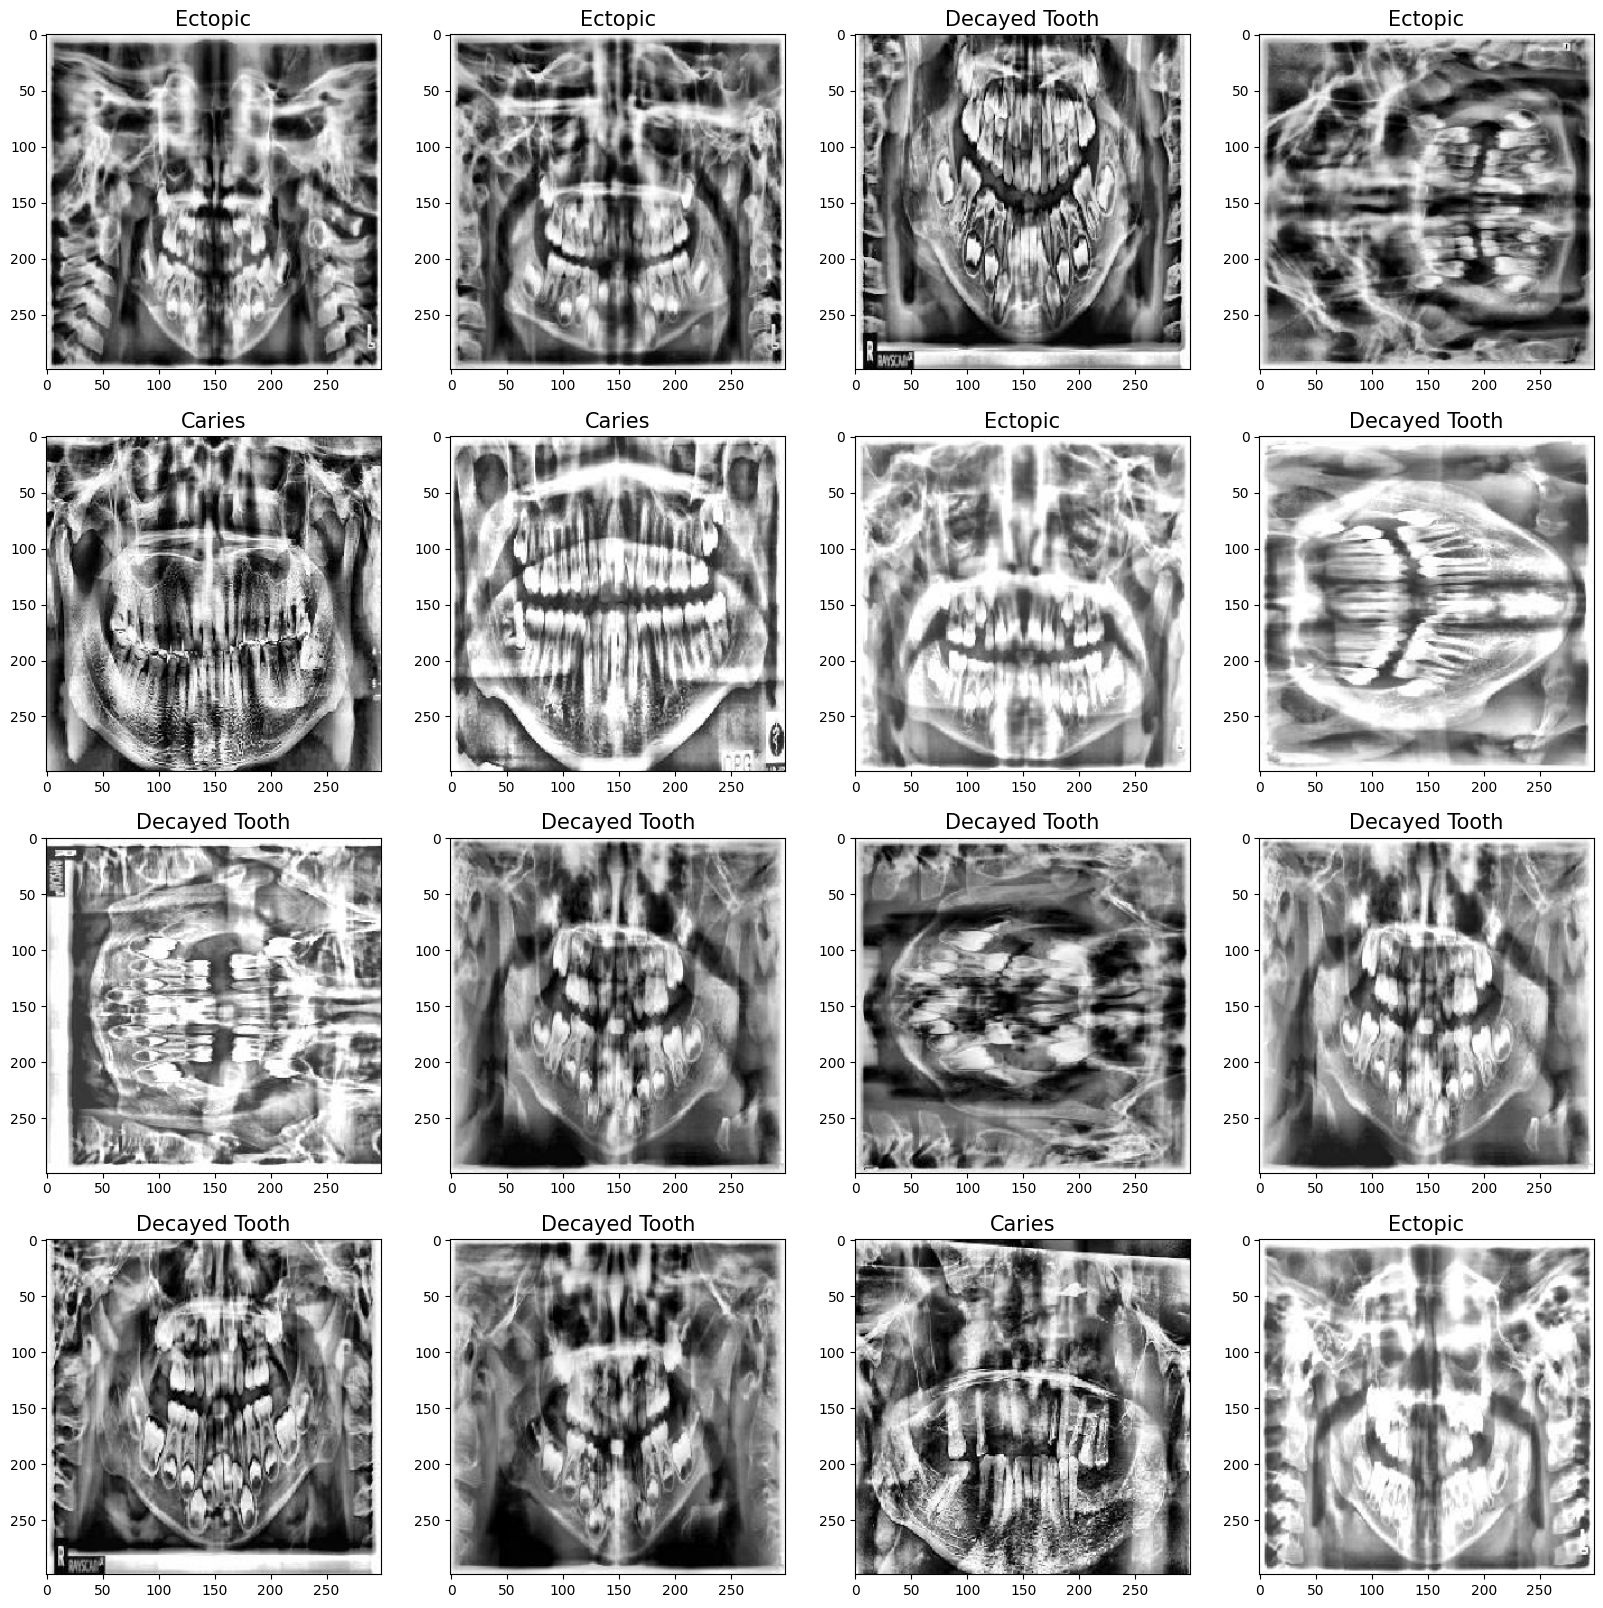

In [12]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(ts_gen)

plt.figure(figsize=(20, 20))

for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4, i + 1)
    plt.imshow(image)
    class_name = classes[np.argmax(label)]
    plt.title(class_name, color='k', fontsize=15)

plt.show()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 299, 299, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 149, 149, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, 149, 149, 32  128        ['block1_conv1[0][0]']           
 ation)                         )                                                             

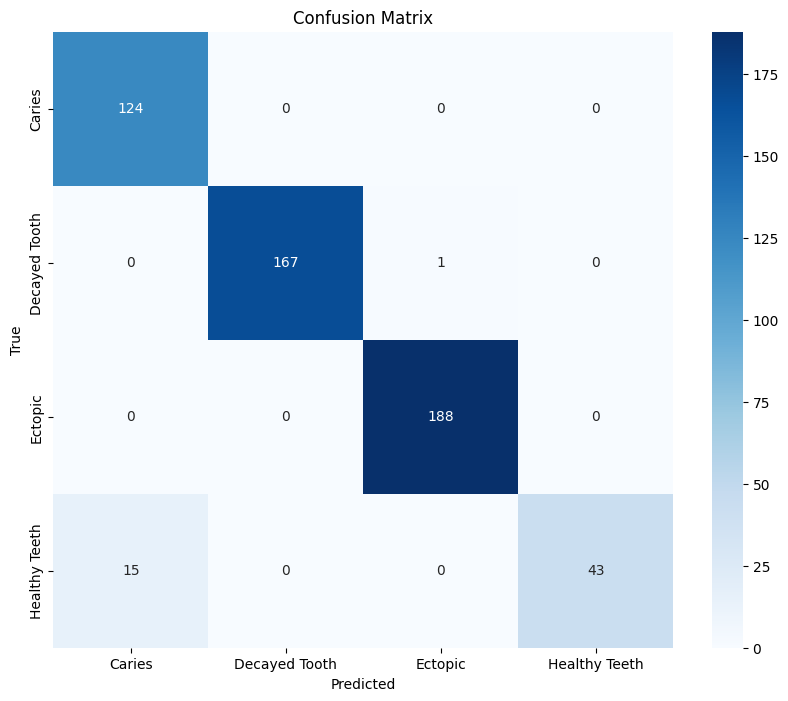

In [13]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Load the pre-trained model (Xception) without the top layer
base_model = Xception(weights='imagenet', include_top=False, input_shape=(*img_size, 3))

# Freeze the base model's layers
base_model.trainable = False

# Build the hypervision model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)  # Prevent overfitting
output = Dense(len(classes), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer=Adamax(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy', Precision(), Recall()])

# Display the model summary
model.summary()

# Callbacks for better training
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Train the model
history = model.fit(tr_gen,
                    validation_data=valid_gen,
                    epochs=25,
                    callbacks=[early_stopping, reduce_lr],
                    verbose=1)

# Evaluate the model on the test dataset
test_loss, test_acc, test_precision, test_recall = model.evaluate(ts_gen, verbose=1)

# Display classification metrics
print(f"Test Accuracy: {test_acc:.2f}")
print(f"Test Precision: {test_precision:.2f}")
print(f"Test Recall: {test_recall:.2f}")

# Confusion matrix
y_true = ts_gen.classes
y_pred = np.argmax(model.predict(ts_gen), axis=1)
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Save the trained model
model.save('hypervision_OPG_model.h5')


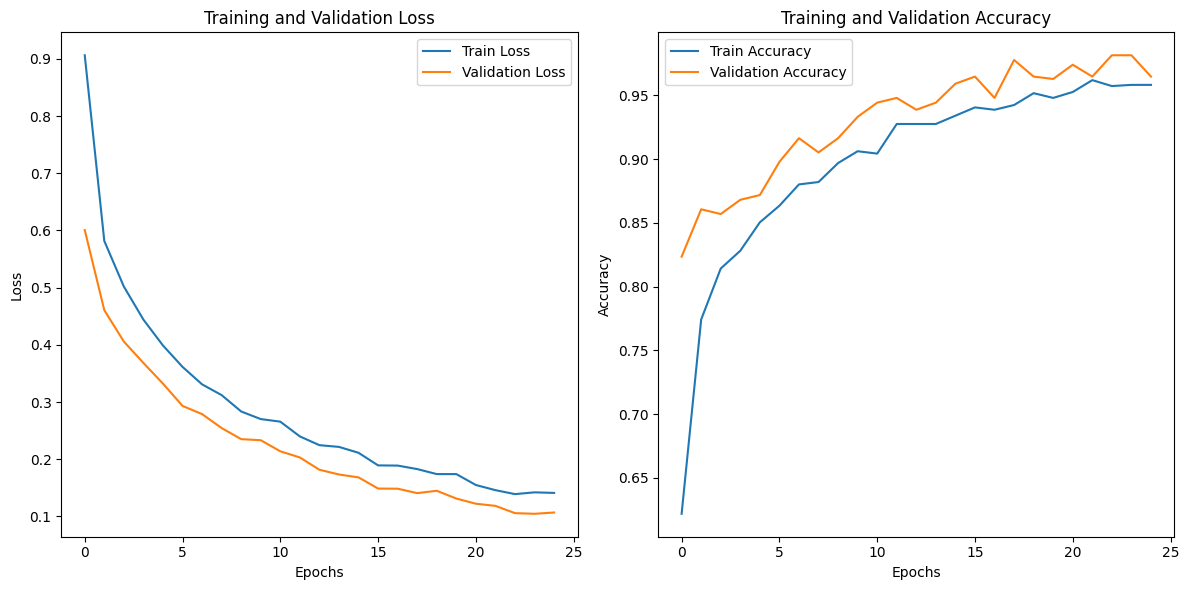

In [16]:
# Plot the training and validation loss
plt.figure(figsize=(12, 6))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()


1/1 [==============================] - 1s 1s/step


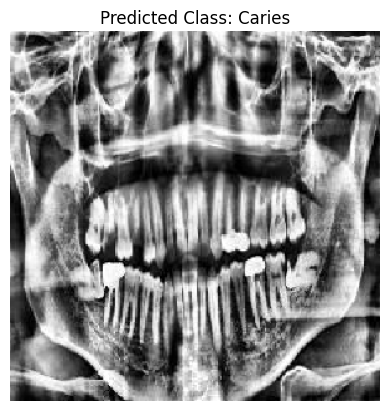

Predicted Class: Caries
Prediction Probabilities: [9.8828399e-01 2.1369737e-03 8.4641382e-05 9.4944229e-03]


In [22]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import os
import matplotlib.pyplot as plt

# Load the trained model
model = load_model('hypervision_OPG_model.h5')

# Define the image size and class labels (updated for 4 classes)
img_size = (299, 299)
class_dict = {0: 'Caries', 1: 'Decayed Tooth', 2: 'Ectopic',  3: 'Healthy Teeth'}  # Correct class names
classes = list(class_dict.values())  # List of class labels in the order the model was trained


def predict_image(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=img_size)  # Resize image to match the model's input size
    img_array = image.img_to_array(img)  # Convert image to numpy array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Rescale image pixel values to [0, 1] (since the model was trained with rescaling)
    
    # Make a prediction
    prediction = model.predict(img_array)  # Predict class probabilities
    predicted_class = np.argmax(prediction, axis=1)  # Get the index of the class with the highest probability
    predicted_label = classes[predicted_class[0]]  # Map the index to the class label
    
    # Display the image and the predicted class label
    plt.imshow(img)
    plt.title(f'Predicted Class: {predicted_label}')
    plt.axis('off')  # Hide axis
    plt.show()

    return predicted_label, prediction[0]

# Example usage:
img_path = 'test/Caries/6_jpg.rf.8fd00e5c4d973382ccb48c5895208c6b.jpg'  # Provide the path to your image
predicted_label, prediction = predict_image(img_path)

print(f"Predicted Class: {predicted_label}")
print(f"Prediction Probabilities: {prediction}")


1/1 [==============================] - 1s 1s/step


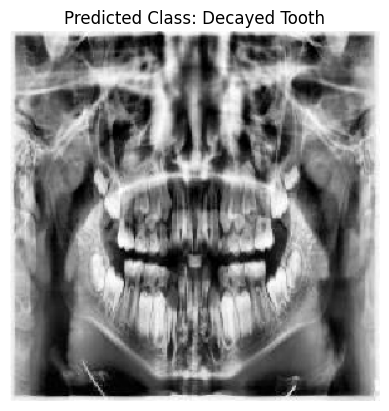

Predicted Class: Decayed Tooth
Prediction Probabilities: [8.8135428e-05 8.9401364e-01 1.0559036e-01 3.0781716e-04]


In [23]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import os
import matplotlib.pyplot as plt

# Load the trained model
model = load_model('hypervision_OPG_model.h5')

# Define the image size and class labels (updated for 4 classes)
img_size = (299, 299)
class_dict = {0: 'Caries', 1: 'Decayed Tooth', 2: 'Ectopic',  3: 'Healthy Teeth'}  # Correct class names
classes = list(class_dict.values())  # List of class labels in the order the model was trained


def predict_image(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=img_size)  # Resize image to match the model's input size
    img_array = image.img_to_array(img)  # Convert image to numpy array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Rescale image pixel values to [0, 1] (since the model was trained with rescaling)
    
    # Make a prediction
    prediction = model.predict(img_array)  # Predict class probabilities
    predicted_class = np.argmax(prediction, axis=1)  # Get the index of the class with the highest probability
    predicted_label = classes[predicted_class[0]]  # Map the index to the class label
    
    # Display the image and the predicted class label
    plt.imshow(img)
    plt.title(f'Predicted Class: {predicted_label}')
    plt.axis('off')  # Hide axis
    plt.show()

    return predicted_label, prediction[0]

# Example usage:
img_path = 'test/Decayed Tooth/426_jpg.rf.3ac4e0b5d904ea5d00872e3eba1fd359.jpg'  # Provide the path to your image
predicted_label, prediction = predict_image(img_path)

print(f"Predicted Class: {predicted_label}")
print(f"Prediction Probabilities: {prediction}")


1/1 [==============================] - 1s 1s/step


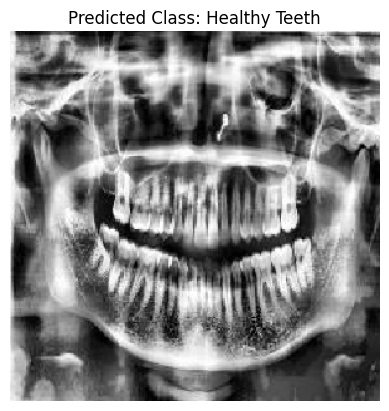

Predicted Class: Healthy Teeth
Prediction Probabilities: [0.34385452 0.00400458 0.00089329 0.65124756]


In [24]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import os
import matplotlib.pyplot as plt

# Load the trained model
model = load_model('hypervision_OPG_model.h5')

# Define the image size and class labels (updated for 4 classes)
img_size = (299, 299)
class_dict = {0: 'Caries', 1: 'Decayed Tooth', 2: 'Ectopic',  3: 'Healthy Teeth'}  # Correct class names
classes = list(class_dict.values())  # List of class labels in the order the model was trained


def predict_image(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=img_size)  # Resize image to match the model's input size
    img_array = image.img_to_array(img)  # Convert image to numpy array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Rescale image pixel values to [0, 1] (since the model was trained with rescaling)
    
    # Make a prediction
    prediction = model.predict(img_array)  # Predict class probabilities
    predicted_class = np.argmax(prediction, axis=1)  # Get the index of the class with the highest probability
    predicted_label = classes[predicted_class[0]]  # Map the index to the class label
    
    # Display the image and the predicted class label
    plt.imshow(img)
    plt.title(f'Predicted Class: {predicted_label}')
    plt.axis('off')  # Hide axis
    plt.show()

    return predicted_label, prediction[0]

# Example usage:
img_path = 'test/Healthy Teeth/27_jpg.rf.344874918cd61f89c19627d5e23dd311.jpg'  # Provide the path to your image
predicted_label, prediction = predict_image(img_path)

print(f"Predicted Class: {predicted_label}")
print(f"Prediction Probabilities: {prediction}")


1/1 [==============================] - 1s 1s/step


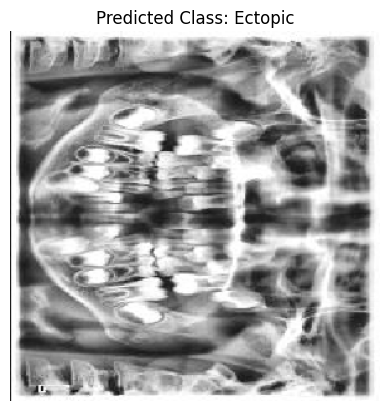

Predicted Class: Ectopic
Prediction Probabilities: [1.3524267e-05 9.6050380e-03 9.9036813e-01 1.3260926e-05]


In [25]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import os
import matplotlib.pyplot as plt

# Load the trained model
model = load_model('hypervision_OPG_model.h5')

# Define the image size and class labels (updated for 4 classes)
img_size = (299, 299)
class_dict = {0: 'Caries', 1: 'Decayed Tooth', 2: 'Ectopic',  3: 'Healthy Teeth'}  # Correct class names
classes = list(class_dict.values())  # List of class labels in the order the model was trained


def predict_image(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=img_size)  # Resize image to match the model's input size
    img_array = image.img_to_array(img)  # Convert image to numpy array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Rescale image pixel values to [0, 1] (since the model was trained with rescaling)
    
    # Make a prediction
    prediction = model.predict(img_array)  # Predict class probabilities
    predicted_class = np.argmax(prediction, axis=1)  # Get the index of the class with the highest probability
    predicted_label = classes[predicted_class[0]]  # Map the index to the class label
    
    # Display the image and the predicted class label
    plt.imshow(img)
    plt.title(f'Predicted Class: {predicted_label}')
    plt.axis('off')  # Hide axis
    plt.show()

    return predicted_label, prediction[0]

# Example usage:
img_path = 'test/Ectopic/12204161838-OMER-ALI-CAKICI-2021-6YAS_bmp_jpg.rf.5d123450f1275cd438044430c7fa50f5.jpg'  # Provide the path to your image
predicted_label, prediction = predict_image(img_path)

print(f"Predicted Class: {predicted_label}")
print(f"Prediction Probabilities: {prediction}")
